In [4]:
import pandas as pd
import matplotlib.pyplot as plt
files = [
    "C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Sales Data 2020.csv",
    "C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Sales Data 2021.csv",
    "C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Sales Data 2022.csv"
]
sales = pd.concat(pd.read_csv(i) for i in files)


customer = pd.read_csv("C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Customer Lookup.csv",encoding = "latin1")

product = pd.read_csv("C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Product Lookup.csv")

territory = pd.read_csv("C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Territory Lookup.csv")

product_category = pd.read_csv("C:/Users/DELL/Desktop/Adventure Work/AdventureWorks Raw Data/AdventureWorks Product Categories Lookup.csv")

sales['CustomerKey'] = sales['CustomerKey'].astype(str)

sales['CustomerKey'] =  sales['CustomerKey'].str.replace(r"\D",'', regex = True)
customer['CustomerKey'] =  customer['CustomerKey'].str.replace(r"\D",'', regex = True)

#sales['CustomerKey'] = sales['CustomerKey'].astype(int)

#customer['CustomerKey'] = customer['CustomerKey'].astype(int)

territory = territory.rename(columns = {'SalesTerritoryKey':'TerritoryKey'})  

df = sales.merge(customer , on = "CustomerKey",how = "left")\
    .merge(product,on = "ProductKey", how = "left")\
    .merge(territory,on = "TerritoryKey",how = "left")

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['BirthDate'] = pd.to_datetime(df['BirthDate'])
df['StockDate'] = pd.to_datetime(df['StockDate'])

def todf(x):
    return pd.DataFrame(x)

In [5]:
#Adding Revenue

df['Revenue'] = df['OrderQuantity'] * df['ProductPrice']

# Adding CustomerAge
df['CustomerAge'] = 2025 - df['BirthDate'].dt.year

# Addind AgeGroup age = 45 - 115 

bins = list(range(45,119,15))
labels = [f"{bins[i]} - {bins[i+1]-1}" for i in range(len(bins)-1)]

df["AgeGroup"] = pd.cut(df["CustomerAge"],bins=bins,labels=labels,right=False)

df['Margin'] = df["ProductPrice"] - df['ProductCost']

df['TotalCost'] = df['OrderQuantity'] * df['ProductCost']

df['Profit'] = df['Revenue'] - df['TotalCost']



In [6]:
df.columns

Index(['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey',
       'TerritoryKey', 'OrderLineItem', 'OrderQuantity', 'Prefix', 'FirstName',
       'LastName', 'BirthDate', 'MaritalStatus', 'Gender', 'EmailAddress',
       'AnnualIncome', 'TotalChildren', 'EducationLevel', 'Occupation',
       'HomeOwner', 'ProductSubcategoryKey', 'ProductSKU', 'ProductName',
       'ModelName', 'ProductDescription', 'ProductColor', 'ProductSize',
       'ProductStyle', 'ProductCost', 'ProductPrice', 'Region', 'Country',
       'Continent', 'Revenue', 'CustomerAge', 'AgeGroup', 'Margin',
       'TotalCost', 'Profit'],
      dtype='object')

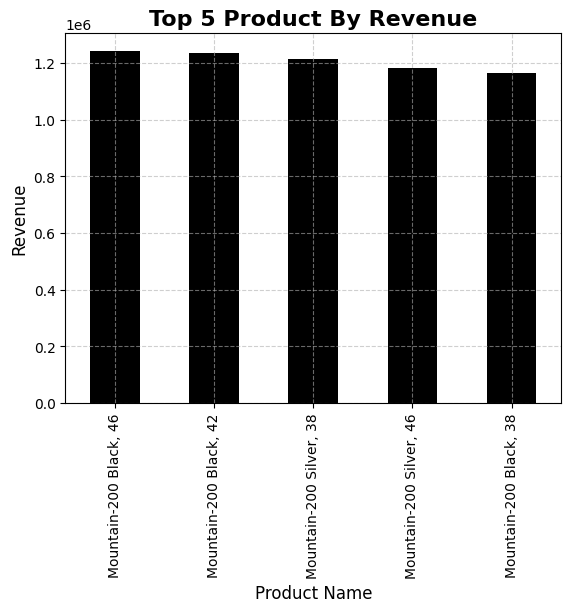

In [7]:
df.groupby('ProductName')['Revenue'].sum().round().nlargest(5).plot(
    kind = 'bar',
    color = 'black',
    linestyle="-",
    linewidth=2,
    
)
plt.title("Top 5 Product By Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Product Name", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

In [8]:
Profit_Margin = ((df['Profit'].sum()/df['Revenue'].sum())*100).round()

In [9]:
todf(df.groupby(df['OrderDate'].dt.year)['Revenue'].sum().round().sort_values(ascending = False).nlargest(3))

,Revenue
OrderDate,
2021,9324204.0
2022,9185449.0
2020,6404934.0


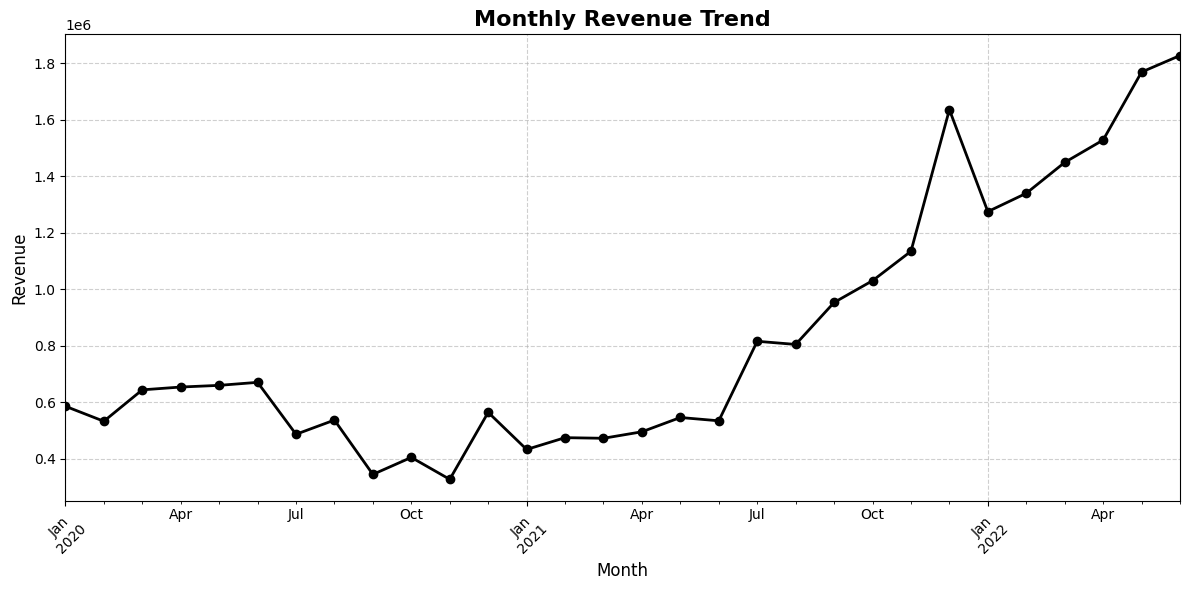

In [ ]:
import matplotlib.pyplot as plt

# Group by year + month
monthly_revenue = (
    df.groupby(df['OrderDate'].dt.to_period("M"))['Revenue']
    .sum()
    .sort_index()
)

# Plot
plt.figure(figsize=(12,6))
a = monthly_revenue.plot(
    kind="line",
    color="black",
    linestyle="-",
    linewidth=2,
    marker="o",
    markersize=6
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


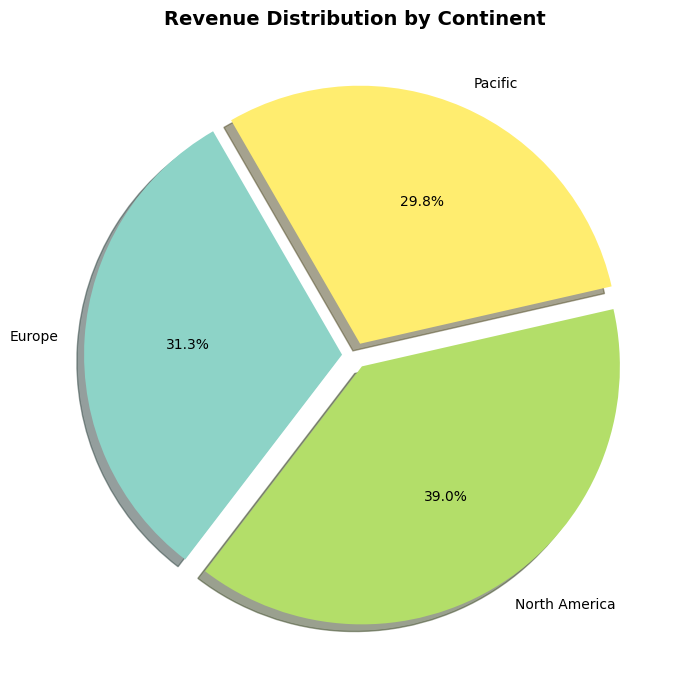

In [11]:
df.groupby('Continent')['Revenue'].sum().round().plot(
    kind='pie',
    autopct='%1.1f%%',     # Show percentages with 1 decimal place
    startangle=120,        # Rotate for better layout
    shadow=True,           # Add shadow effect
    explode=[0.05]*len(df['Continent'].unique()),  # Pop out slices
    figsize=(7,7),         # Set figure size
    cmap='Set3'            # Nice pastel colormap
)

plt.title("Revenue Distribution by Continent", fontsize=14, weight='bold')
plt.ylabel('')  # Hide y-axis label
plt.tight_layout()
plt.show()

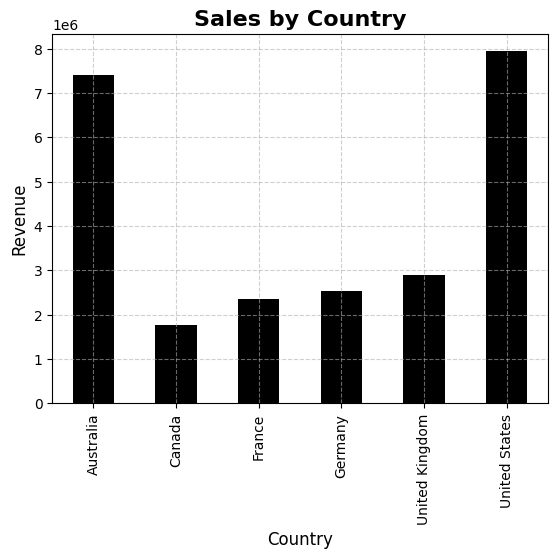

In [12]:
df.groupby('Country')['Revenue'].sum().round().plot(
    kind = 'bar',
    color = 'black'
)
plt.title("Sales by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

In [13]:
Top_5_Product = df.groupby('ProductName')['Revenue'].sum().round().sort_values(ascending = False).nlargest(5)
todf(Top_5_Product)

,Revenue
ProductName,
"Mountain-200 Black, 46",1241754.0
"Mountain-200 Black, 42",1233557.0
"Mountain-200 Silver, 38",1213852.0
"Mountain-200 Silver, 46",1182781.0
"Mountain-200 Black, 38",1165937.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_14452\3998358284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")['Revenue'].sum().round().plot(


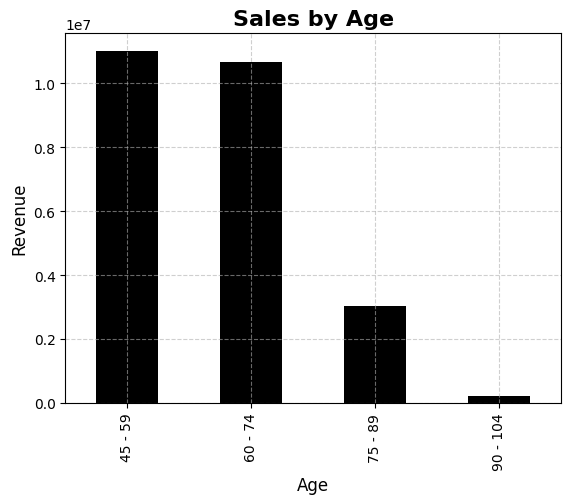

In [14]:
df.groupby("AgeGroup")['Revenue'].sum().round().plot(
    kind = "bar",
    color = 'black',
    linestyle="-",
    linewidth=2,
)
plt.title("Sales by Age", fontsize=16, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

<Axes: xlabel='Occupation'>

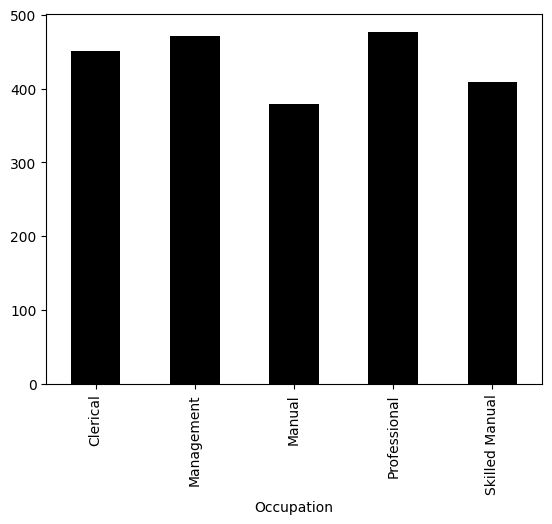

In [15]:
df.groupby('Occupation')['Revenue'].mean().round().plot(
    kind = 'bar',
    color = 'black'
)


<Figure size 500x500 with 0 Axes>

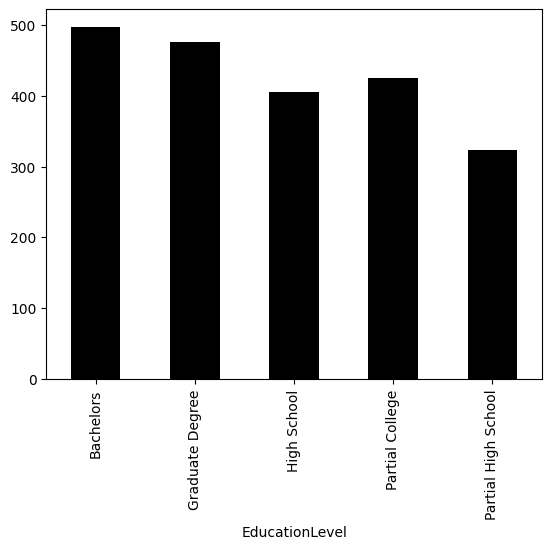

<Figure size 500x500 with 0 Axes>

In [16]:
# Need to work on this make education level simple

EduRevenue = df.groupby('EducationLevel')['Revenue'].mean().round()
EduRevenue.plot(
    kind = 'bar',
    color = 'black'
)
plt.figure(figsize = (5,5))

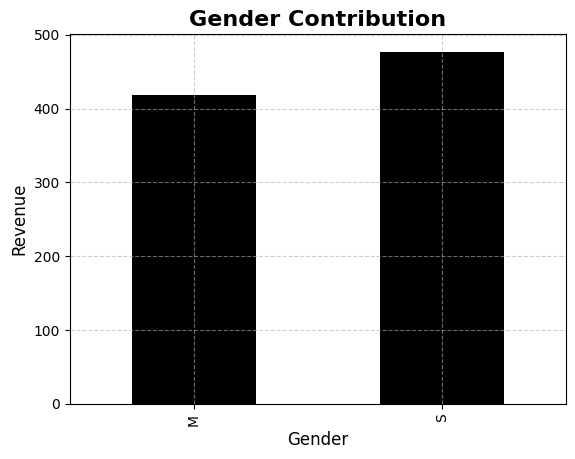

In [17]:
MartialRevenue = df.groupby('MaritalStatus')['Revenue'].mean().round()
MartialRevenue.plot(
    kind = 'bar',
    color = 'black'
)
plt.title("Gender Contribution", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

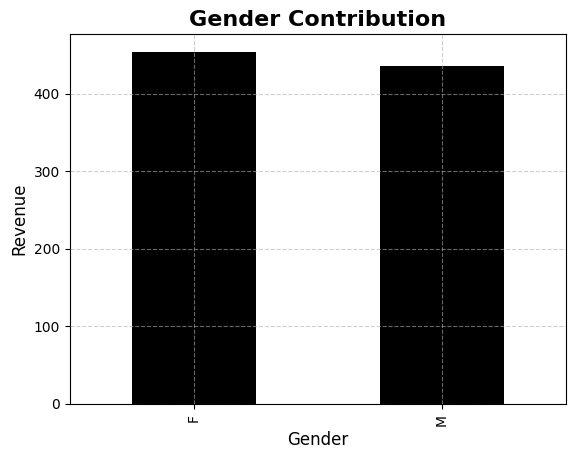

In [18]:
GenderRevenue = df.groupby('Gender')['Revenue'].mean().round()
GenderRevenue.plot(
    kind = 'bar',
    color = 'black'
)
plt.title("Gender Contribution", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

<Figure size 800x500 with 0 Axes>

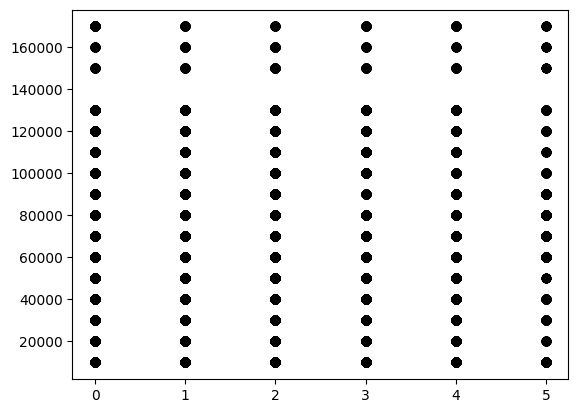

<Figure size 800x500 with 0 Axes>

In [19]:
plt.scatter(
    x = df['TotalChildren'],
    y = df['AnnualIncome'],
    color = 'black'
)
plt.figure(figsize = (8,5))

<Axes: xlabel='Region'>

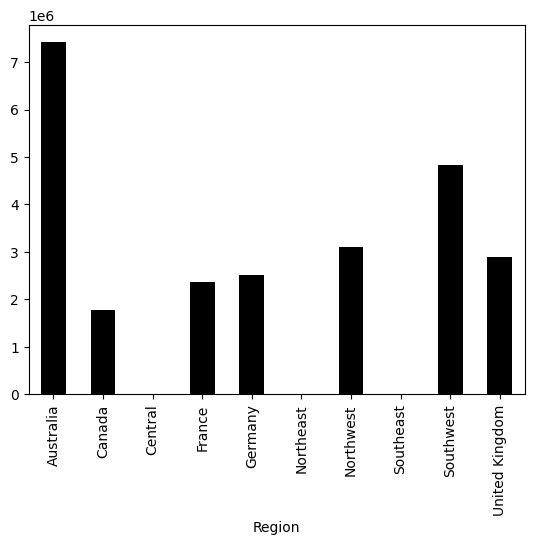

In [20]:
RegionRevenue = df.groupby('Region')['Revenue'].sum().round()
RegionRevenue.plot(
    kind = 'bar',
    color = 'black'
)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56046 entries, 0 to 56045
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   OrderDate              56046 non-null  datetime64[ns]
 1   StockDate              56046 non-null  datetime64[ns]
 2   OrderNumber            56046 non-null  object        
 3   ProductKey             56046 non-null  int64         
 4   CustomerKey            56046 non-null  object        
 5   TerritoryKey           56046 non-null  int64         
 6   OrderLineItem          56046 non-null  int64         
 7   OrderQuantity          56046 non-null  int64         
 8   Prefix                 55666 non-null  object        
 9   FirstName              56046 non-null  object        
 10  LastName               56046 non-null  object        
 11  BirthDate              56046 non-null  datetime64[ns]
 12  MaritalStatus          56046 non-null  object        
 13  G

In [22]:
df.isnull().sum()

OrderDate                    0
StockDate                    0
OrderNumber                  0
ProductKey                   0
CustomerKey                  0
TerritoryKey                 0
OrderLineItem                0
OrderQuantity                0
Prefix                     380
FirstName                    0
LastName                     0
BirthDate                    0
MaritalStatus                0
Gender                     380
EmailAddress                 0
AnnualIncome                 0
TotalChildren                0
EducationLevel               0
Occupation                   0
HomeOwner                    0
ProductSubcategoryKey        0
ProductSKU                   0
ProductName                  0
ModelName                    0
ProductDescription           0
ProductColor             26878
ProductSize                  0
ProductStyle                 0
ProductCost                  0
ProductPrice                 0
Region                       0
Country                      0
Continen